In [1]:
import numpy as np

In [2]:
import subprocess
result = subprocess.run(['find', '/home/users/bidyut', '-name', 'all_bar_data_Relative_OLD_and_WRONG.pkl'], 
                       capture_output=True, text=True)
print(result.stdout)

/home/users/bidyut/UoE/20260218_Monsoons/all_bar_data_Relative_OLD_and_WRONG.pkl



In [3]:
import os
# Check what directory the save script was running from
print(os.getcwd())

/home/users/bidyut/UoE/20260218_Monsoons


In [4]:
import pickle
from pathlib import Path

SAVE_DIR = Path('/home/users/bidyut/UoE/20260218_Monsoons')
with open(SAVE_DIR / 'all_bar_data_Relative.pkl', 'rb') as f:
    all_bar_data = pickle.load(f)

print(list(all_bar_data.keys()))

['MSEsfc_bar_data_G6sulfur20212100_minus_HIST19212000', 'MSEsfc_bar_data_SSP24520212100_minus_HIST19212000', 'MSEsfc_bar_data_SSP58520212100_minus_HIST19212000', 'MSEsfc_bar_data_G6sulfur20212100_minus_SSP24520212100', 'MSEsfc_bar_data_G6sulfur20212100_minus_SSP58520212100']


In [5]:
# all_bar_data is a dict — access individual results by key:
# # ── pull named datasets from the single store dict ──────────────────────────
bar_SSP585_HIST     = all_bar_data['MSEsfc_bar_data_SSP58520212100_minus_HIST19212000']
bar_SSP245_HIST     = all_bar_data['MSEsfc_bar_data_SSP24520212100_minus_HIST19212000']
bar_G6s_HIST        = all_bar_data['MSEsfc_bar_data_G6sulfur20212100_minus_HIST19212000']
bar_G6s_SSP245      = all_bar_data['MSEsfc_bar_data_G6sulfur20212100_minus_SSP24520212100']
bar_G6s_SSP585      = all_bar_data['MSEsfc_bar_data_G6sulfur20212100_minus_SSP58520212100']



In [6]:
print(type(bar_SSP585_HIST['per_model_all']))
print(np.array(bar_SSP585_HIST['per_model_all']).shape)
# print(bar_SSP585_HIST['per_model_all'])

<class 'list'>
(8, 5)


Available labels: ['Land', 'Ocean', 'N. America', 'S. America', 'Sahel', 'S. Africa', 'India', 'N. Australia']


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

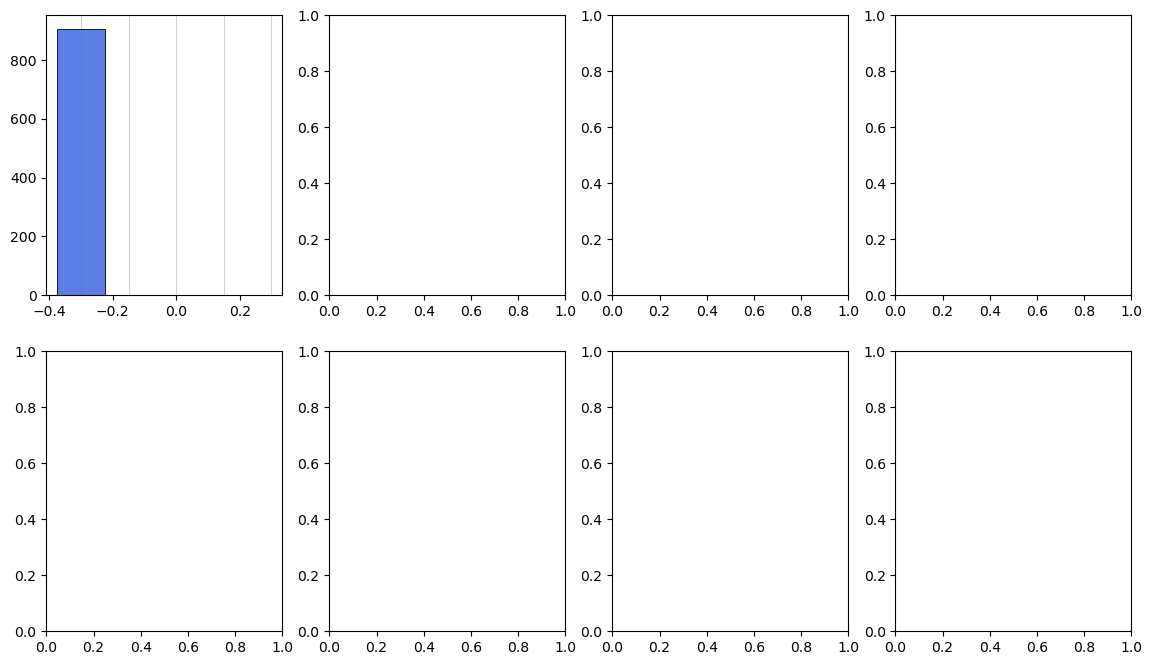

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 4, figsize=(14, 8))

width   = 0.15
# FIX: Re-center offsets for 5 datasets (was 6 with TRMM at index 0)
offsets = np.array([-2, -1, 0, 1, 2]) * width

# FIX: Re-index colors from 0 (was starting at 1 to skip TRMM's gray)
bar_color = ['royalblue', 'forestgreen', 'gold', 'tomato', 'mediumpurple']

datasets = [
    (bar_SSP585_HIST, float(offsets[0]), 's', bar_color[0], 'SSP585−HIST'),
    (bar_SSP245_HIST, float(offsets[1]), 'o', bar_color[1], 'SSP245−HIST'),
    (bar_G6s_HIST,    float(offsets[2]), 'D', bar_color[2], 'G6sulfur−HIST'),
    (bar_G6s_SSP245,  float(offsets[3]), '^', bar_color[3], 'G6sulfur−SSP245'),
    (bar_G6s_SSP585,  float(offsets[4]), 'X', bar_color[4], 'G6sulfur−SSP585'),
]

panel_layout = [
    (0, 0, 'Land'),
    (0, 1, 'Ocean'),
    (0, 2, 'N. America'),
    (0, 3, 'S. America'),
    (1, 0, 'Sahel'),
    (1, 1, 'S. Africa'),
    (1, 2, 'India'),
    (1, 3, 'N. Australia'),
]

all_labels = bar_SSP585_HIST['labels']
print("Available labels:", all_labels)

rng = np.random.default_rng(42)
# x   = np.array([0])
x = 0  # was: x = np.array([0])

for row, col, panel_label in panel_layout:
    ax = axes[row, col]
    try:
        i_label = list(all_labels).index(panel_label)
    except ValueError:
        ax.set_visible(False)
        print(f"Label '{panel_label}' not found, skipping")
        continue

    # Gray vertical guide lines at each bar center
    # Gray vertical guide lines at each bar center
    for offset in offsets:
        ax.axvline(x + offset, color='lightgray', linewidth=0.8,
                   linestyle='-', zorder=1)

    for data, offset, marker, color, leg_label in datasets:
        val = data['means'][i_label]
        ax.bar(x + offset, val, width=width,
               color=color, edgecolor='k', linewidth=0.7,
               alpha=0.85, zorder=3)
        # pm = data['per_model_all'][i_label]
        pm = np.array(data['per_model_all'][i_label])[:, -1]   # → 5 values, one per model
        ax.scatter(np.full(len(pm), x + offset), pm,
                   marker=marker, color='k', s=30, zorder=5,
                   alpha=0.8, edgecolors='white', linewidths=0.4)

    ax.axhline(0, color='k', linewidth=0.8, linestyle='--', zorder=2)
    ax.set_xticks([])
    ax.set_xlim(-0.6, 0.6)
    ax.set_title(panel_label, fontsize=11, fontweight='bold')
    ax.set_ylabel('$\\Delta$MSE (J kg$^{-1}$)', fontsize=9)
    ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7, zorder=2)

# Shared legend
legend_patches = [
    mpatches.Patch(facecolor=bar_color[0], edgecolor='k', label='SSP585−HIST'),
    mpatches.Patch(facecolor=bar_color[1], edgecolor='k', label='SSP245−HIST'),
    mpatches.Patch(facecolor=bar_color[2], edgecolor='k', label='G6sulfur−HIST'),
    mpatches.Patch(facecolor=bar_color[3], edgecolor='k', label='G6sulfur−SSP245'),
    mpatches.Patch(facecolor=bar_color[4], edgecolor='k', label='G6sulfur−SSP585'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='k',
               markersize=7, alpha=0.8, label='Individual models'),
]

fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=10, bbox_to_anchor=(0.5, -0.06))
plt.suptitle('Multi-model mean MSE$_{sfc}$ response (Relative to the Tropical mean)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig("MSEsfc_change_panels.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 4, figsize=(14, 8))

width   = 0.15
# FIX: Re-center offsets for 5 datasets (was 6 with TRMM at index 0)
offsets = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]) * width

# FIX: Re-index colors from 0 (was starting at 1 to skip TRMM's gray)
bar_color = ['royalblue', 'forestgreen', 'gold', 'tomato', 'mediumpurple']

datasets = [
    (None,            float(offsets[0]), 's', 'gray',        'HIST−OBS'),       # blank placeholder
    (bar_SSP585_HIST, float(offsets[1]), 's', bar_color[0], 'SSP585−HIST'),
    (bar_SSP245_HIST, float(offsets[2]), 'o', bar_color[1], 'SSP245−HIST'),
    (bar_G6s_HIST,    float(offsets[3]), 'D', bar_color[2], 'G6sulfur−HIST'),
    (bar_G6s_SSP245,  float(offsets[4]), '^', bar_color[3], 'G6sulfur−SSP245'),
    (bar_G6s_SSP585,  float(offsets[5]), 'X', bar_color[4], 'G6sulfur−SSP585'),
]

panel_layout = [
    (0, 0, 'Land'),
    (0, 1, 'Ocean'),
    (0, 2, 'N. America'),
    (0, 3, 'S. America'),
    (1, 0, 'Sahel'),
    (1, 1, 'S. Africa'),
    (1, 2, 'India'),
    (1, 3, 'N. Australia'),
]

all_labels = bar_SSP585_HIST['labels']
print("Available labels:", all_labels)

rng = np.random.default_rng(42)
# x   = np.array([0])
x = 0  # was: x = np.array([0])

for row, col, panel_label in panel_layout:
    ax = axes[row, col]
    try:
        i_label = list(all_labels).index(panel_label)
    except ValueError:
        ax.set_visible(False)
        print(f"Label '{panel_label}' not found, skipping")
        continue

    # Gray vertical guide lines at each bar center
    # Gray vertical guide lines at each bar center
    for offset in offsets:
        ax.axvline(x + offset, color='lightgray', linewidth=0.8,
                   linestyle='-', zorder=1)

    for data, offset, marker, color, leg_label in datasets:
        if data is None:
            continue                          # skip blank bar slot
        val = data['means'][i_label]
        ax.bar(x + offset, val, width=width,
               color=color, edgecolor='k', linewidth=0.7,
               alpha=0.85, zorder=3)
        pm = np.array(data['per_model_all'][i_label])[:, -1]
        ax.scatter(np.full(len(pm), x + offset), pm,
                   marker=marker, color='k', s=30, zorder=5,
                   alpha=0.8, edgecolors='white', linewidths=0.4)

    ax.axhline(0, color='k', linewidth=0.8, linestyle='--', zorder=2)
    ax.set_xticks([])
    ax.set_xlim(-0.6, 0.6)
    ax.set_title(panel_label, fontsize=11, fontweight='bold')
    ax.set_ylabel('$\\Delta$MSE (J kg$^{-1}$)', fontsize=9)
    ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7, zorder=2)

# Shared legend
legend_patches = [
    mpatches.Patch(facecolor=bar_color[0], edgecolor='k', label='SSP585−HIST'),
    mpatches.Patch(facecolor=bar_color[1], edgecolor='k', label='SSP245−HIST'),
    mpatches.Patch(facecolor=bar_color[2], edgecolor='k', label='G6sulfur−HIST'),
    mpatches.Patch(facecolor=bar_color[3], edgecolor='k', label='G6sulfur−SSP245'),
    mpatches.Patch(facecolor=bar_color[4], edgecolor='k', label='G6sulfur−SSP585'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='k',
               markersize=7, alpha=0.8, label='Individual models'),
]

fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=10, bbox_to_anchor=(0.5, -0.06))
plt.suptitle('Multi-model mean MSE$_{sfc}$ response (Relative to the Tropical mean)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("MSEsfc_change_panels_withBLANK.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 4, figsize=(14, 8))

width   = 0.15
offsets = np.array([-0.5, 0.5]) * width  # only 2 datasets

bar_color = ['royalblue', 'forestgreen']

datasets = [
    (bar_SSP585_HIST, offsets[0], 's', bar_color[0], 'SSP585−HIST'),
    (bar_SSP245_HIST, offsets[1], 'o', bar_color[1], 'SSP245−HIST'),
]

panel_layout = [
    (0, 0, 'Land'),
    (0, 1, 'Ocean'),
    (0, 2, 'N. America'),
    (0, 3, 'S. America'),
    (1, 0, 'Sahel'),
    (1, 1, 'S. Africa'),
    (1, 2, 'India'),
    (1, 3, 'N. Australia'),
]

all_labels = bar_SSP585_HIST['labels']
print("Available labels:", all_labels)

rng = np.random.default_rng(42)
x   = 0.0

for row, col, panel_label in panel_layout:
    ax = axes[row, col]

    try:
        i_label = list(all_labels).index(panel_label)
    except ValueError:
        ax.set_visible(False)
        print(f"Label '{panel_label}' not found, skipping")
        continue

    # Gray vertical guide lines at each bar center
    for offset in offsets:
        ax.axvline(float(x + offset), color='lightgray', linewidth=0.8,
                   linestyle='-', zorder=1)

    for data, offset, marker, color, leg_label in datasets:
        val = data['means'][i_label]
        ax.bar(float(x + offset), val, width=width,
               color=color, edgecolor='k', linewidth=0.7,
               alpha=0.85, zorder=3)
        pm = np.array(data['per_model_all'][i_label])[:, -1]   # → 5 values, one per model
        ax.scatter(np.full(len(pm), x + offset), pm,
                   marker=marker, color='k', s=30, zorder=5,
                   alpha=0.8, edgecolors='white', linewidths=0.4)

    ax.axhline(0, color='k', linewidth=0.8, linestyle='--', zorder=2)
    ax.set_xticks([])
    ax.set_xlim(-0.3, 0.3)   # tighter xlim for 2 bars
    ax.set_title(panel_label, fontsize=11, fontweight='bold')
    ax.set_ylabel('$\\Delta$MSE$_{sfc}$ (J kg$^{-1}$)', fontsize=9)  # corrected units
    ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7, zorder=2)

# Shared legend — only 2 patches + individual models
legend_patches = [
    mpatches.Patch(facecolor=bar_color[0], edgecolor='k', label='SSP585−HIST'),
    mpatches.Patch(facecolor=bar_color[1], edgecolor='k', label='SSP245−HIST'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='k',
               markersize=7, alpha=0.8, label='Individual models'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, -0.04))

plt.suptitle('Multi-model mean MSE$_{sfc}$ response',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig("MSEsfc_change_panels.png", dpi=150, bbox_inches="tight")
plt.show()